In [ ]:
!unzip "/content/Archaeological DetectionFinal.v2i.yolov8.zip"
!ls

Archive:  /content/Archaeological DetectionFinal.v2i.yolov8.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/output_123_g_png.rf.8c433488ecb60d755d3aed6883705a3c.jpg  
 extracting: test/images/output_125_b_png.rf.ff694ddf2082abaa592799fdccb1596f.jpg  
 extracting: test/images/output_137_b_png.rf.9319d44dffa2181b6402a971fcc2d99d.jpg  
 extracting: test/images/output_64_b_png.rf.bcdaa0020c8f5c1ab9d53b7f5724bdf5.jpg  
 extracting: test/images/output_697_g_png.rf.afa7f6e0f8e6bb06b123c75d3e93a5c9.jpg  
 extracting: test/images/output_709_1_b_png.rf.9de4686e6cdefad4c21504a65dd13e23.jpg  
 extracting: test/images/raaw6_jpg.rf.808b2b14edad52b1630337f81d9836e5.jpg  
   creating: test/labels/
  inflating: test/labels/output_123_g_png.rf.8c433488ecb60d755d3aed6883705a3c.txt  
  inflating: test/labels/output_125_b_png.rf.ff694ddf2082abaa592799fdccb1596f.txt  
 

In [ ]:
import os
import cv2
import numpy as np

image_dir = "train/images"
label_dir = "train/labels"
mask_dir = "train/masks"

os.makedirs(mask_dir, exist_ok=True)

for img_name in os.listdir(image_dir):

    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:
            cls, x, y, bw, bh = map(float, line.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            # ONLY 2 CLASSES FOR SEGMENTATION
            if int(cls) == 0:   # ruins
                mask[y1:y2, x1:x2] = 1
            elif int(cls) == 1: # vegetation
                mask[y1:y2, x1:x2] = 2
            # ignore artifacts

    cv2.imwrite(os.path.join(mask_dir, img_name.replace(".jpg", ".png")), mask)

print("Masks created")

Masks created


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SegDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        # IMAGE
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.resize(img, (256,256))
        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        # MASK
        mask_name = img_name.replace(".jpg", ".png")
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (256,256))

        #  CRITICAL FIX
        mask = np.clip(mask, 0, 2)
        mask = mask.astype(np.int64)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [ ]:
train_dataset = SegDataset("train/images", "train/masks")

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=3,
    activation=None
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss = nn.CrossEntropyLoss()   #  SAFE LOSS

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss_value = loss(outputs, masks)

        loss_value.backward()
        optimizer.step()

        total_loss += loss_value.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 30.72130274772644
Epoch 2, Loss: 25.064271211624146
Epoch 3, Loss: 24.215103447437286
Epoch 4, Loss: 24.791366040706635
Epoch 5, Loss: 24.125299751758575


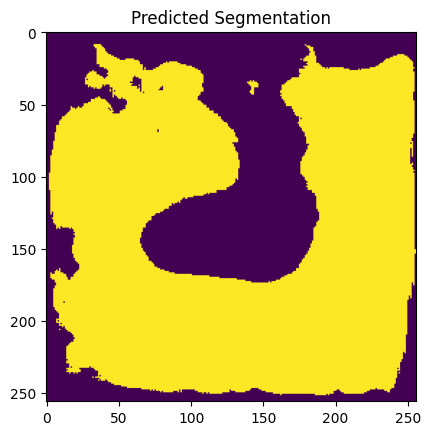

In [ ]:
model.eval()

img, mask = train_dataset[0]

pred = model(img.unsqueeze(0).to(device))
pred = torch.argmax(pred, 1).cpu().numpy()[0]

import matplotlib.pyplot as plt

plt.imshow(pred)
plt.title("Predicted Segmentation")
plt.show()

In [ ]:
def iou(pred, mask):
    intersection = np.logical_and(pred, mask)
    union = np.logical_or(pred, mask)
    return intersection.sum() / union.sum()

In [ ]:
def dice(pred, mask):
    intersection = (pred * mask).sum()
    return (2 * intersection) / (pred.sum() + mask.sum())

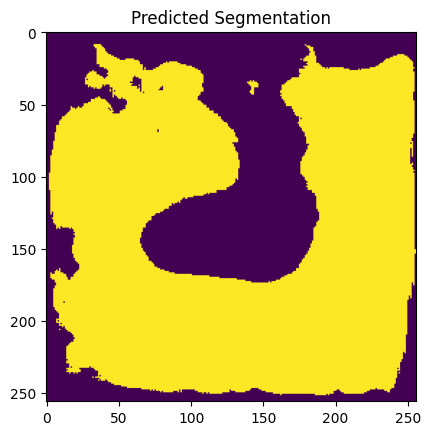

IoU Score: 0.5076149061055751
Dice Score: 0.636760168800312


In [ ]:
model.eval()

img, mask = train_dataset[0]

pred = model(img.unsqueeze(0).to(device))
pred = torch.argmax(pred, 1).cpu().numpy()[0]

true_mask = mask.numpy()

import matplotlib.pyplot as plt

plt.imshow(pred)
plt.title("Predicted Segmentation")
plt.show()

# Metrics
iou_value = iou(pred, true_mask)
dice_value = dice(pred, true_mask)

print("IoU Score:", iou_value)
print("Dice Score:", dice_value)